### Phase 2 — Geometry + Linker Modeling
#### Objective
Evaluate whether linker descriptors improve CO₂ uptake predictions
beyond the four existing geometry features.
## Models
1. Geometry-only Random Forest
2. Geometry + Linker Random Forest

Use identical MOF rows and train/validation/test splits for both models
at all five pressures.

---

In [11]:
# Step 1: import the libraries and connect the notebook to the project.
# Import pandas for loading and working with the dataset
import pandas as pd
# Import NumPy for checking numerical descriptor values
import numpy as np
# Import tools for locating project files
from pathlib import Path
import sys
# Define the project folder
project_root = Path("/home/susan/mof-co2-adsorption")

# Allow this notebook to import functions from src
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import  linker descriptor function
from src.linker_descriptors import calculate_all_descriptors

# Confirm that the function comes from the script
print(calculate_all_descriptors.__module__)

src.linker_descriptors


In [12]:
# Locate the processed-data folder
processed_folder = project_root / "data" / "processed"

# Display CSV and pickle filenames
for file in sorted(processed_folder.iterdir()):
    if file.suffix in {".csv", ".pkl"}:
        print(file.name)

df_chem.csv
hmof_linker_descriptors.pkl
hmof_linker_extracted_final.csv
hmof_linker_extracted_final.pkl
rows_with_both_problems.csv


In [18]:
#Step 3: check whether the pickle file includes linker descriptors
# Load your saved linker dataset
df_chemistry = pd.read_pickle(
    processed_folder / "hmof_linker_descriptors.pkl"
)

# Check its size
print("Dataset shape:", df_chemistry.shape)

# Find descriptor columns such as linker_1_MolWt
descriptor_columns = [
    column for column in df_chemistry.columns
    if any(column.startswith(f"linker_{i}_") for i in range(1, 14))
]

print("Descriptor columns:", len(descriptor_columns))
print(df_chemistry.columns)
df_chemistry[['linker_1','linker_13']].head()

Dataset shape: (25928, 222)
Descriptor columns: 195
Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       ...
       'linker_13_MaxPartialCharge', 'linker_13_MinPartialCharge',
       'linker_13_NOCount', 'linker_13_NumHeteroatoms', 'linker_13_LogP',
       'linker_13_LabuteASA', 'linker_13_RotatableBonds',
       'linker_13_FractionCSP3', 'linker_13_PEOE_VSA1', 'linker_13_PEOE_VSA2'],
      dtype='object', length=222)


,linker_1,linker_13
0,O=C([O-])c1ccc(C(=O)[O-])cc1,None
1,O=C([O-])c1ccc(C(=O)[O-])cc1,None
2,O=C([O-])c1cc(F)c(C(=O)[O-])c(F)c1F,None
3,COc1cc(C(=O)[O-])cc(OC)c1C(=O)[O-],None
4,CCc1cc(C(=O)[O-])c(CC)c(CC)c1C(=O)[O-],None


In [14]:
# step 4 : check whether missing descriptors occur only where a linker is absent.
# Collect validation results for each linker position
checks = []

for i in range(1, 14):
    linker = f"linker_{i}"

    # Identify rows containing a linker SMILES
    present = (
        df_chemistry[linker].notna()
        & df_chemistry[linker].fillna("").str.strip().ne("")
    )

    # Select this linker's descriptor columns
    columns = [
        col for col in descriptor_columns
        if col.startswith(f"{linker}_")
    ]
    values = df_chemistry[columns]

    # Check for missing or infinite descriptor values
    invalid_values = values.isna() | values.isin([np.inf, -np.inf])

    # Summarize results for this linker position
    checks.append({
        "linker": linker,
        "descriptor_count": len(columns),
        "present_linkers": int(present.sum()),
        "absent_linkers": int((~present).sum()),
        "present_with_invalid_values": int(
            (present & invalid_values.any(axis=1)).sum()
        ),
        "absent_with_descriptor_values": int(
            (~present & values.notna().any(axis=1)).sum()
        ),
    })

# Display the validation table
pd.DataFrame(checks)

,linker,descriptor_count,present_linkers,absent_linkers,present_with_invalid_values,absent_with_descriptor_values
0,linker_1,15,25928,0,0,0
1,linker_2,15,24899,1029,0,0
2,linker_3,15,20414,5514,0,0
3,linker_4,15,1250,24678,0,0
4,linker_5,15,261,25667,0,0
5,linker_6,15,83,25845,0,0
6,linker_7,15,29,25899,0,0
7,linker_8,15,15,25913,0,0
8,linker_9,15,10,25918,0,0
9,linker_10,15,4,25924,0,0


In [15]:
# Step 5: identify the MOF row with the invalid linker_1 descriptor value
linker = "linker_1"
columns = [col for col in descriptor_columns if col.startswith(f"{linker}_")]

present = (
    df_chemistry[linker].notna()
    & df_chemistry[linker].fillna("").str.strip().ne("")
)
values = df_chemistry[columns]
invalid_values = values.isna() | values.isin([np.inf, -np.inf])

problem_mask = present & invalid_values.any(axis=1)
problem_rows = df_chemistry.loc[problem_mask, ["filename", linker] + columns]

print("Number of affected rows:", problem_mask.sum())
problem_rows

Number of affected rows: 0


,filename,linker_1,linker_1_MolWt,linker_1_TPSA,linker_1_NumHAcceptors,linker_1_NumHDonors,linker_1_NumAromaticRings,linker_1_MaxPartialCharge,linker_1_MinPartialCharge,linker_1_NOCount,linker_1_NumHeteroatoms,linker_1_LogP,linker_1_LabuteASA,linker_1_RotatableBonds,linker_1_FractionCSP3,linker_1_PEOE_VSA1,linker_1_PEOE_VSA2


---
### Descriptor Validation — Missing and Infinite Values

The project’s chemistry dataset contains 25,929 MOFs and 195 linker
descriptor columns: 15 descriptors for each of 13 linker positions.

The validation check showed that:

- All 13 linker positions have the expected 15 descriptor columns.
- Absent linker positions contain only missing descriptor values, as expected.
- One MOF has a linker present in `linker_1` but at least one missing
  (`NaN`) or infinite (`inf`) descriptor value.
- No such issues were found in occupied positions `linker_2`–`linker_13`.

---

In [19]:
df_chemistry.isna().sum()

filename                        0
lcd                             0
pld                             0
void_fraction                   0
surface_area_m2g                0
                            ...  
linker_13_LabuteASA         25927
linker_13_RotatableBonds    25927
linker_13_FractionCSP3      25927
linker_13_PEOE_VSA1         25927
linker_13_PEOE_VSA2         25927
Length: 222, dtype: int64

Missing-value summary

The dataset contains 25,928 MOFs. The four structural features (lcd, pld, void_fraction, and surface_area_m2g) have no missing values.

The linker columns represent up to 13 linker positions per MOF. When a MOF has fewer linkers, its unused positions contain None, and the corresponding RDKit descriptor columns contain NaN. For example, each linker_13 descriptor is missing in 25,927 of 25,928 rows, indicating that very few MOFs use that position.

These expected missing values do not require removing the MOFs. For modeling, we plan to summarize each descriptor across the linkers present in a MOF and include the number of linkers as a feature. We still need to verify that no descriptor is missing for a linker that is present.

In [46]:
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)

In [41]:
# Create 4 strtuctural feature for XGBOOST and all pressures 
structure_cols =  ["lcd", "pld", "void_fraction", "surface_area_m2g"]

target_cols = ["CO2_uptake_0.01bar_molkg",
    "CO2_uptake_0.05bar_molkg",
    "CO2_uptake_0.1bar_molkg",
    "CO2_uptake_0.5bar_molkg",
    "CO2_uptake_2.5bar_molkg", ]

# Spliting df_chemistry first : 2 steps splittings: df_train 60 % and df_temp : 40%
df_train, df_temp = train_test_split(
    df_chemistry,
    test_size=0.40,
    random_state=SEED,)

# we split df_temp to two test set of valid and test : 20% each of them 
df_valid, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=SEED,
)
# Checking the splitting of dataset: 
print(df_train.shape, df_valid.shape, df_test.shape)
# First model: 4 structural features 

# First model: 4 structural features
X_train_4 = df_train[structure_cols]
X_valid_4 = df_valid[structure_cols]
X_test_4 = df_test[structure_cols]

# The five targets, kept together for now
y_train = df_train[target_cols]
y_valid = df_valid[target_cols]
y_test = df_test[target_cols]

print("4-feature inputs:", X_train_4.shape)
print("Targets:", y_train.shape)

(15556, 222) (5186, 222) (5186, 222)
4-feature inputs: (15556, 4)
Targets: (15556, 5)


In [42]:
# full numeric feature set for the second model:
descriptor_cols = [
    col for col in df_chemistry.columns
    if col.startswith("linker_")
    and pd.api.types.is_numeric_dtype(df_chemistry[col])
]
# Only columns starting with "linker_"Only numeric columns (your RDKit descriptors) 
# Excludes non-numeric columns like linker_1, linker_2 (string names)
# Combine structural + descriptor features
all_feature_cols = structure_cols + descriptor_cols

# Build train/valid/test matrices
X_train_all = df_train[all_feature_cols]
X_valid_all = df_valid[all_feature_cols]
X_test_all = df_test[all_feature_cols]

print("Descriptor columns:", len(descriptor_cols))  # Expected: 195
print("All-feature inputs:", X_train_all.shape)       # Expected: 199 columns

Descriptor columns: 195
All-feature inputs: (15556, 199)


In [48]:
from xgboost import XGBRegressor

# Create a list to store results for all five CO₂ pressures
results_4_features = []

# Train a separate XGBoost model for each CO₂ uptake target
for target in target_cols:

    # Create XGBoost using the parameters selected at 0.01 bar
    model_xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Train the model using the four structural features
    model_xgb.fit(X_train_4, df_train[target])

    # Predict uptake for the training rows
    train_pred = model_xgb.predict(X_train_4)

    # Predict uptake for the validation rows
    valid_pred = model_xgb.predict(X_valid_4)

    # Calculate metrics and store the results for this pressure
    results_4_features.append({
        "pressure": target,
        "train_MAE": mean_absolute_error(df_train[target], train_pred),
        "valid_MAE": mean_absolute_error(df_valid[target], valid_pred),
        "train_RMSE": np.sqrt(mean_squared_error(df_train[target], train_pred)),
        "valid_RMSE": np.sqrt(mean_squared_error(df_valid[target], valid_pred)),
        "train_R2": r2_score(df_train[target], train_pred),
        "valid_R2": r2_score(df_valid[target], valid_pred),
    })

# Convert the results into a table
results_4_features = pd.DataFrame(results_4_features)

# Display the results rounded to four decimal places
display(results_4_features.round(4))

,pressure,train_MAE,valid_MAE,train_RMSE,valid_RMSE,train_R2,valid_R2
0,CO2_uptake_0.01bar_molkg,0.0709,0.0775,0.1471,0.1653,0.5415,0.4400
1,CO2_uptake_0.05bar_molkg,0.1992,0.2120,0.3296,0.3611,0.6046,0.5574
2,CO2_uptake_0.1bar_molkg,0.2968,0.3092,0.4558,0.4840,0.6205,0.5953
3,CO2_uptake_0.5bar_molkg,0.6529,0.6671,0.8934,0.9070,0.6302,0.6212
4,CO2_uptake_2.5bar_molkg,1.1455,1.1707,1.5277,1.5438,0.6583,0.6322


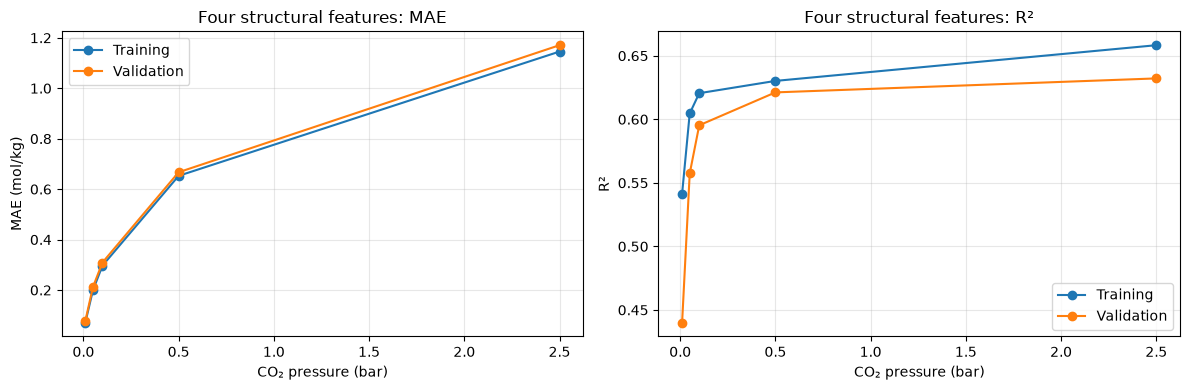

In [51]:
import matplotlib.pyplot as plt

# Use pressure values in the same order as the results table
pressures = [0.01, 0.05, 0.1, 0.5, 2.5]

# Create separate panels for MAE and R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compare training and validation MAE
axes[0].plot(pressures, results_4_features["train_MAE"],
             marker="o", label="Training")
axes[0].plot(pressures, results_4_features["valid_MAE"],
             marker="o", label="Validation")
axes[0].set_title("Four structural features: MAE")
axes[0].set_xlabel("CO₂ pressure (bar)")
axes[0].set_ylabel("MAE (mol/kg)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Compare training and validation R²
axes[1].plot(pressures, results_4_features["train_R2"],
             marker="o", label="Training")
axes[1].plot(pressures, results_4_features["valid_R2"],
             marker="o", label="Validation")
axes[1].set_title("Four structural features: R²")
axes[1].set_xlabel("CO₂ pressure (bar)")
axes[1].set_ylabel("R²")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Display the figure
plt.tight_layout()
plt.show()

----
The XGBoost model’s validation R² increased from 0.440 at 0.01 bar to 0.632 at 2.5 bar, indicating that the four structural features explain more of the variation in uptake at higher pressures. Validation MAE also increased, from 0.0775 to 1.1707 mol/kg, but uptake values are larger at higher pressures, so MAE values across pressures should not be interpreted on their own as evidence that the model performs worse.

The training and validation curves remain fairly close, suggesting limited overfitting. The largest R² gap occurs at 0.01 bar, where structural features alone may leave more of the uptake variation unexplained.

In [50]:
# Create a list to store results for all five pressures
results_with_linkers = []

# Train a separate model for each CO₂ uptake target
for target in target_cols:

    # Use the same XGBoost settings as the four-feature baseline
    model_xgb_linkers = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Train with structural features and linker descriptors
    model_xgb_linkers.fit(X_train_all, df_train[target])

    # Predict on the training and validation rows
    train_pred = model_xgb_linkers.predict(X_train_all)
    valid_pred = model_xgb_linkers.predict(X_valid_all)

    # Store the metrics for this pressure
    results_with_linkers.append({
        "pressure": target,
        "train_MAE": mean_absolute_error(df_train[target], train_pred),
        "valid_MAE": mean_absolute_error(df_valid[target], valid_pred),
        "train_RMSE": np.sqrt(mean_squared_error(df_train[target], train_pred)),
        "valid_RMSE": np.sqrt(mean_squared_error(df_valid[target], valid_pred)),
        "train_R2": r2_score(df_train[target], train_pred),
        "valid_R2": r2_score(df_valid[target], valid_pred),
    })

# Display the linker-model results
results_with_linkers = pd.DataFrame(results_with_linkers)
display(results_with_linkers.round(4))

,pressure,train_MAE,valid_MAE,train_RMSE,valid_RMSE,train_R2,valid_R2
0,CO2_uptake_0.01bar_molkg,0.0549,0.0625,0.1160,0.1346,0.7150,0.6288
1,CO2_uptake_0.05bar_molkg,0.1425,0.1579,0.2420,0.2755,0.7869,0.7425
2,CO2_uptake_0.1bar_molkg,0.2044,0.2253,0.3200,0.3596,0.8130,0.7766
3,CO2_uptake_0.5bar_molkg,0.4160,0.4422,0.5712,0.6110,0.8488,0.8281
4,CO2_uptake_2.5bar_molkg,0.7038,0.7472,0.9366,0.9897,0.8716,0.8488


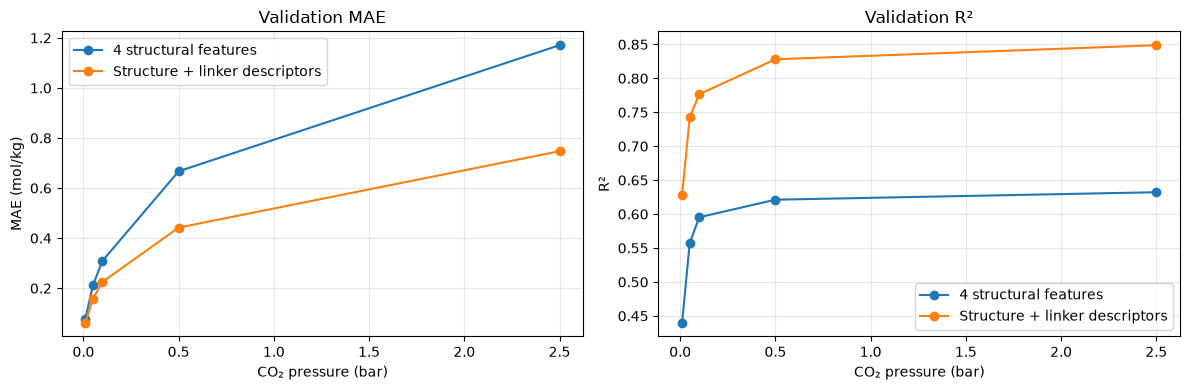

In [52]:
# Create separate panels for validation MAE and validation R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compare validation MAE; lower is better
axes[0].plot(pressures, results_4_features["valid_MAE"],
             marker="o", label="4 structural features")
axes[0].plot(pressures, results_with_linkers["valid_MAE"],
             marker="o", label="Structure + linker descriptors")
axes[0].set_title("Validation MAE")
axes[0].set_xlabel("CO₂ pressure (bar)")
axes[0].set_ylabel("MAE (mol/kg)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Compare validation R²; higher is better
axes[1].plot(pressures, results_4_features["valid_R2"],
             marker="o", label="4 structural features")
axes[1].plot(pressures, results_with_linkers["valid_R2"],
             marker="o", label="Structure + linker descriptors")
axes[1].set_title("Validation R²")
axes[1].set_xlabel("CO₂ pressure (bar)")
axes[1].set_ylabel("R²")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Display the figure
plt.tight_layout()
plt.show()

---
Effect of adding linker descriptors

On the same validation split, adding linker descriptors reduced MAE and increased R² at all five CO₂ pressures. At 0.01 bar, MAE fell from 0.0775 to 0.0625 mol/kg and R² rose from 0.4400 to 0.6288. At 2.5 bar, MAE fell from 1.1707 to 0.7472 mol/kg and R² rose from 0.6322 to 0.8488.

The plot shows that linker descriptors add predictive information beyond the four structural features. These results describe validation performance; they do not establish a causal effect of specific linker properties on adsorption.

In [53]:
from xgboost import XGBRegressor

# Select the two feature sets from the untouched test rows
X_test_4 = df_test[structure_cols]
X_test_all = df_test[all_feature_cols]

# Store test results for both models
test_results = []

# Evaluate each CO₂ pressure separately
for target in target_cols:

    # Create a fresh four-feature model
    model_4 = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Create a fresh structure + linker model with the same settings
    model_all = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Train both models using the same training rows and target
    model_4.fit(X_train_4, df_train[target])
    model_all.fit(X_train_all, df_train[target])

    # Predict the same test targets with each model
    y_test = df_test[target]
    pred_4 = model_4.predict(X_test_4)
    pred_all = model_all.predict(X_test_all)

    # Save test metrics for side-by-side comparison
    test_results.append({
        "pressure": target,
        "MAE_4": mean_absolute_error(y_test, pred_4),
        "MAE_linkers": mean_absolute_error(y_test, pred_all),
        "RMSE_4": np.sqrt(mean_squared_error(y_test, pred_4)),
        "RMSE_linkers": np.sqrt(mean_squared_error(y_test, pred_all)),
        "R2_4": r2_score(y_test, pred_4),
        "R2_linkers": r2_score(y_test, pred_all),
    })

# Create the comparison table
test_comparison = pd.DataFrame(test_results)

# Calculate the percentage reduction in MAE after adding linker descriptors
test_comparison["MAE_reduction_%"] = (
    (test_comparison["MAE_4"] - test_comparison["MAE_linkers"])
    / test_comparison["MAE_4"]
    * 100
)

# Display the final test comparison
display(test_comparison.round(4))

,pressure,MAE_4,MAE_linkers,RMSE_4,RMSE_linkers,R2_4,R2_linkers,MAE_reduction_%
0,CO2_uptake_0.01bar_molkg,0.0750,0.0611,0.1628,0.1361,0.4521,0.6174,18.5582
1,CO2_uptake_0.05bar_molkg,0.2063,0.1518,0.3464,0.2605,0.5631,0.7530,26.4083
2,CO2_uptake_0.1bar_molkg,0.3069,0.2164,0.4724,0.3421,0.5939,0.7870,29.4884
3,CO2_uptake_0.5bar_molkg,0.6702,0.4323,0.9097,0.5899,0.6117,0.8367,35.4961
4,CO2_uptake_2.5bar_molkg,1.1584,0.7416,1.5436,0.9795,0.6355,0.8532,35.9791


In [55]:
# Keep the validation metrics from the four-feature model
valid_4 = results_4_features[
    ["pressure", "valid_MAE", "valid_R2"]
].rename(columns={
    "valid_MAE": "valid_MAE_4",
    "valid_R2": "valid_R2_4",
})

# Keep the validation metrics from the linker model
valid_linkers = results_with_linkers[
    ["pressure", "valid_MAE", "valid_R2"]
].rename(columns={
    "valid_MAE": "valid_MAE_linkers",
    "valid_R2": "valid_R2_linkers",
})

# Join validation and test results by pressure
validation_vs_test = (
    valid_4
    .merge(valid_linkers, on="pressure")
    .merge(
        test_comparison[
            ["pressure", "MAE_4", "MAE_linkers", "R2_4", "R2_linkers"]
        ],
        on="pressure",
    )
    .rename(columns={
        "MAE_4": "test_MAE_4",
        "MAE_linkers": "test_MAE_linkers",
        "R2_4": "test_R2_4",
        "R2_linkers": "test_R2_linkers",
    })
)

# Calculate test minus validation gaps for each model
for model in ["4", "linkers"]:
    validation_vs_test[f"MAE_gap_{model}"] = (
        validation_vs_test[f"test_MAE_{model}"]
        - validation_vs_test[f"valid_MAE_{model}"]
    )
    validation_vs_test[f"R2_gap_{model}"] = (
        validation_vs_test[f"test_R2_{model}"]
        - validation_vs_test[f"valid_R2_{model}"]
    )

# Display the comparison
display(validation_vs_test.round(4))

,pressure,valid_MAE_4,valid_R2_4,valid_MAE_linkers,valid_R2_linkers,test_MAE_4,test_MAE_linkers,test_R2_4,test_R2_linkers,MAE_gap_4,R2_gap_4,MAE_gap_linkers,R2_gap_linkers
0,CO2_uptake_0.01bar_molkg,0.0775,0.4400,0.0625,0.6288,0.0750,0.0611,0.4521,0.6174,-0.0025,0.0121,-0.0014,-0.0114
1,CO2_uptake_0.05bar_molkg,0.2120,0.5574,0.1579,0.7425,0.2063,0.1518,0.5631,0.7530,-0.0058,0.0057,-0.0061,0.0105
2,CO2_uptake_0.1bar_molkg,0.3092,0.5953,0.2253,0.7766,0.3069,0.2164,0.5939,0.7870,-0.0024,-0.0013,-0.0089,0.0104
3,CO2_uptake_0.5bar_molkg,0.6671,0.6212,0.4422,0.8281,0.6702,0.4323,0.6117,0.8367,0.0031,-0.0094,-0.0099,0.0087
4,CO2_uptake_2.5bar_molkg,1.1707,0.6322,0.7472,0.8488,1.1584,0.7416,0.6355,0.8532,-0.0124,0.0034,-0.0057,0.0044


----

Validation–test consistency: Both XGBoost models produced similar results on the validation and test sets across all five CO₂ pressures. For the model with linker descriptors, the largest MAE difference was 0.0099 mol/kg (at 0.5 bar), and the largest R² difference was 0.0114 (at 0.01 bar). The improvement from adding linker descriptors was therefore observed on both held-out sets, supporting its predictive value on this data split.

----

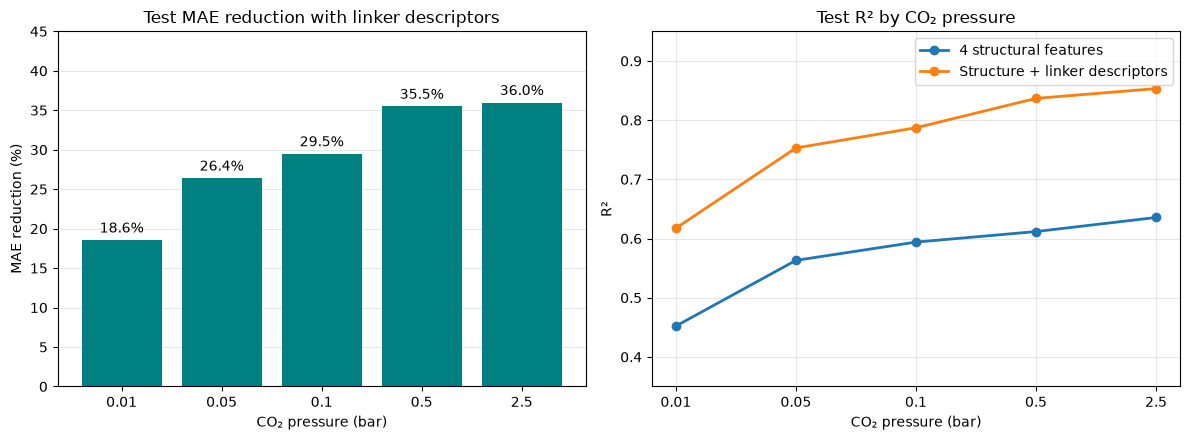

In [54]:
import matplotlib.pyplot as plt

# Use short pressure labels in the same order as test_comparison
pressure_labels = ["0.01", "0.05", "0.1", "0.5", "2.5"]

# Create two panels for the test-set comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot the percentage reduction in test MAE
bars = axes[0].bar(
    pressure_labels,
    test_comparison["MAE_reduction_%"],
    color="teal",
)
axes[0].bar_label(bars, fmt="%.1f%%", padding=3)
axes[0].set_title("Test MAE reduction with linker descriptors")
axes[0].set_xlabel("CO₂ pressure (bar)")
axes[0].set_ylabel("MAE reduction (%)")
axes[0].set_ylim(0, 45)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)

# Plot test R² for both feature sets
axes[1].plot(
    pressure_labels,
    test_comparison["R2_4"],
    marker="o",
    linewidth=2,
    label="4 structural features",
)
axes[1].plot(
    pressure_labels,
    test_comparison["R2_linkers"],
    marker="o",
    linewidth=2,
    label="Structure + linker descriptors",
)
axes[1].set_title("Test R² by CO₂ pressure")
axes[1].set_xlabel("CO₂ pressure (bar)")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0.35, 0.95)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Show the comparison
plt.tight_layout()
plt.show()

---
Test-set conclusion

Adding RDKit linker descriptors to the four structural features improved XGBoost predictions at all five CO₂ pressures. Test MAE decreased by 18.6% at 0.01 bar and by 36.0% at 2.5 bar, with progressively larger percentage reductions across the tested pressures. Test R² also increased at every pressure, from 0.452 to 0.617 at 0.01 bar and from 0.636 to 0.853 at 2.5 bar.

These results show that the linker descriptors provide useful predictive information beyond the four structural properties on this test split. They do not yet identify which linker properties matter most or establish a causal effect on adsorption.

---


Four structural features: CO2_uptake_0.01bar_molkg


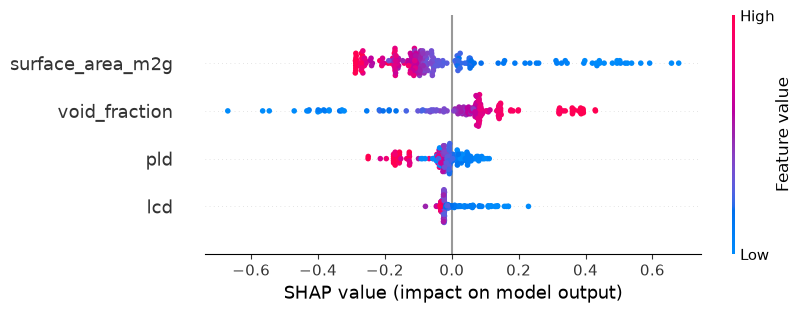


Four structural features: CO2_uptake_0.05bar_molkg


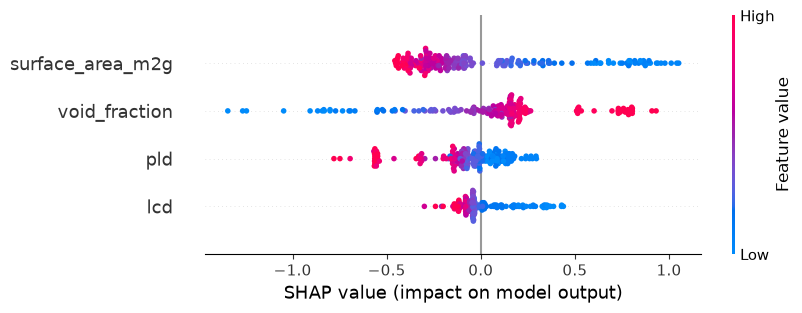


Four structural features: CO2_uptake_0.1bar_molkg


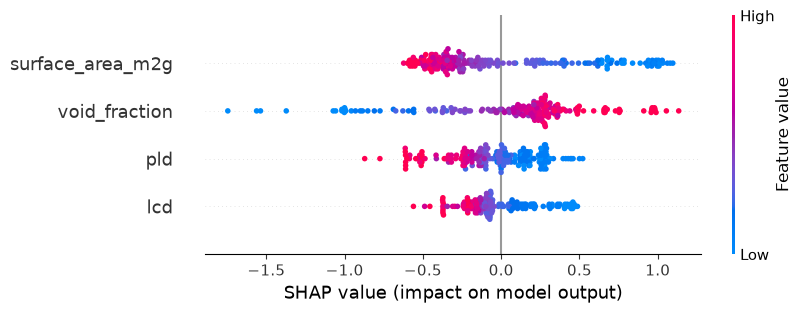


Four structural features: CO2_uptake_0.5bar_molkg


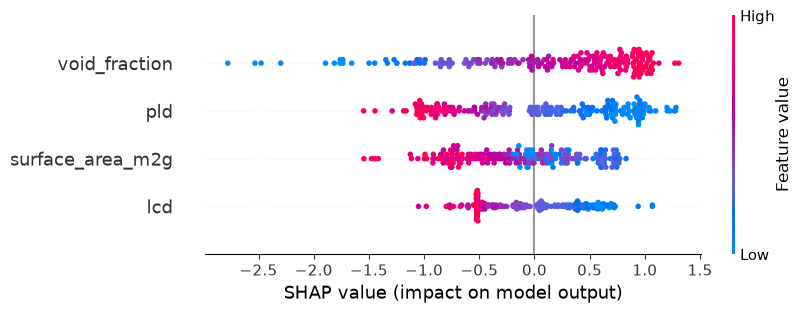


Four structural features: CO2_uptake_2.5bar_molkg


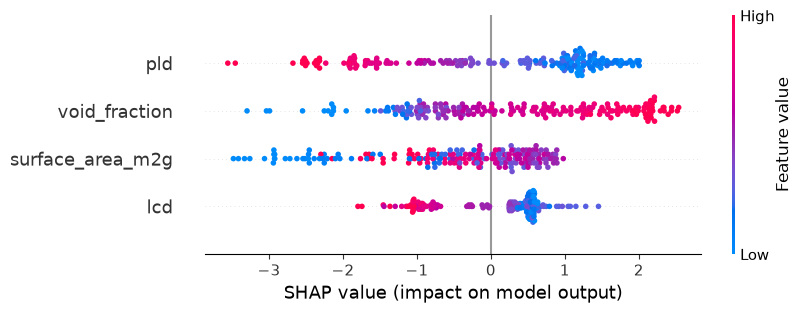

In [58]:
import shap


# Select the same 200 validation rows for every pressure
sample_index = X_valid_4.sample(
    n=min(200, len(X_valid_4)),
    random_state=SEED,
).index

X_shap_4 = X_valid_4.loc[sample_index]

# Store the four-feature SHAP results
shap_results_4 = {}

# Fit and explain one four-feature model per pressure
for target in target_cols:

    # Create the XGBoost model
    model_4 = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Fit using the four structural features
    model_4.fit(X_train_4, df_train[target])

    # Calculate SHAP values for the selected validation rows
    shap_values_4 = shap.TreeExplainer(model_4)(X_shap_4)

    # Save the explanation for this pressure
    shap_results_4[target] = shap_values_4

    # Display the SHAP plot
    print(f"\nFour structural features: {target}")
    shap.plots.beeswarm(shap_values_4, max_display=4)

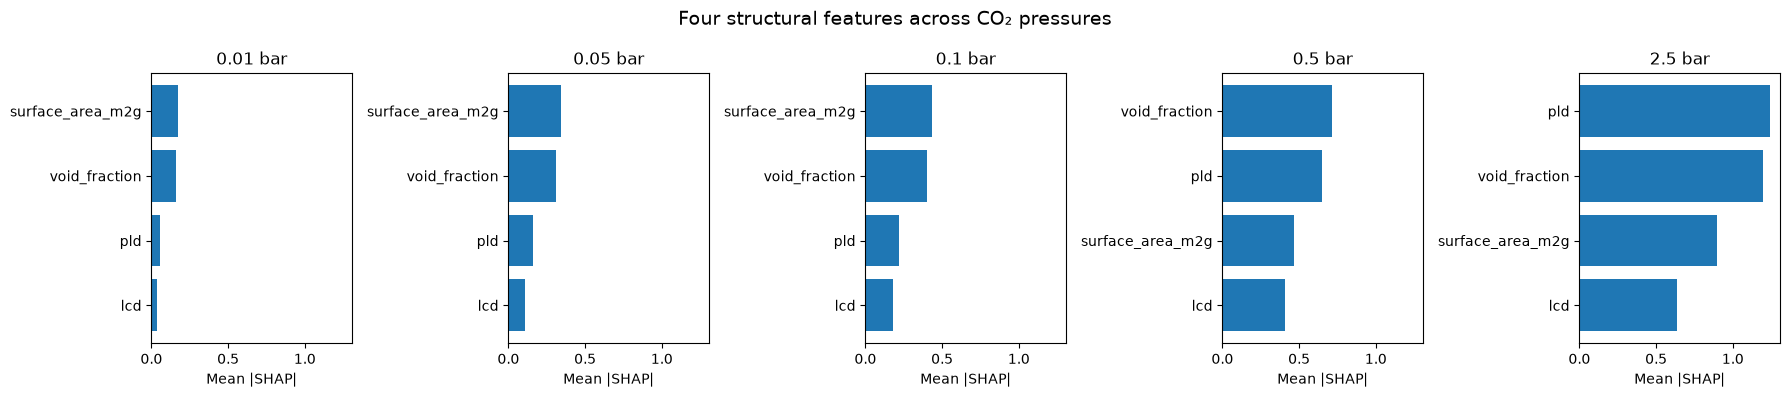

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Create one figure with the four structural features at each pressure
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True)

for ax, target in zip(axes, target_cols):
    # Calculate mean absolute SHAP value for each structural feature
    values = shap_results[target]["four_features"]
    importance = np.abs(values.values).mean(axis=0)
    order = np.argsort(importance)

    # Plot feature importance for this pressure
    ax.barh(np.array(values.feature_names)[order], importance[order])
    ax.set_title(target.split("_")[2].replace("bar", " bar"))
    ax.set_xlabel("Mean |SHAP|")

fig.suptitle("Four structural features across CO₂ pressures", fontsize=14)
plt.tight_layout()
plt.show()


Structure + linker descriptors: CO2_uptake_0.01bar_molkg


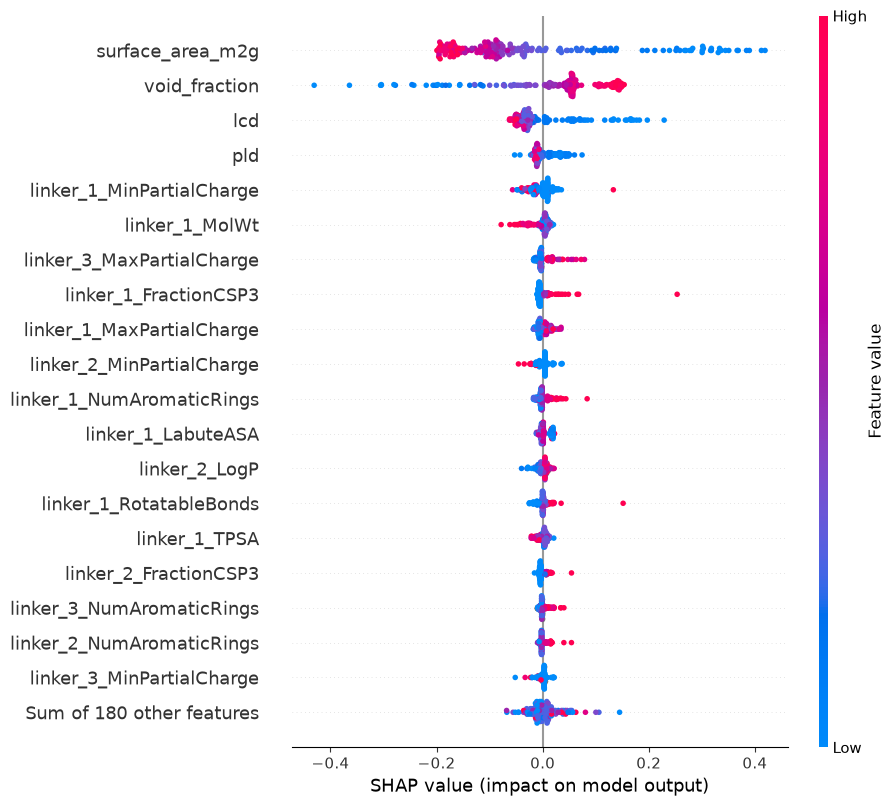


Structure + linker descriptors: CO2_uptake_0.05bar_molkg


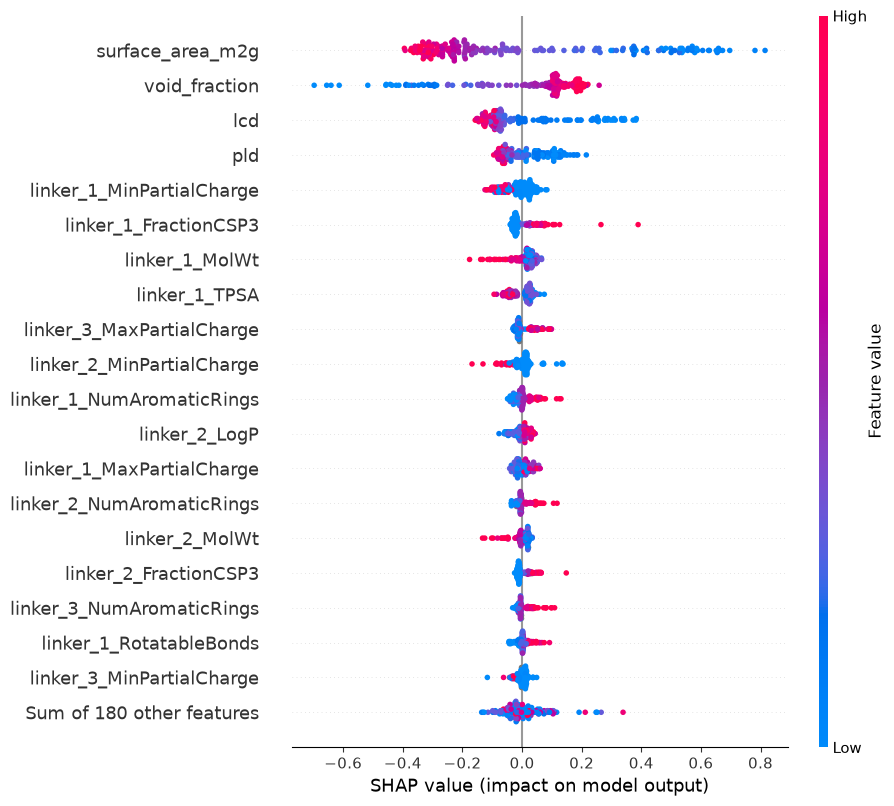


Structure + linker descriptors: CO2_uptake_0.1bar_molkg


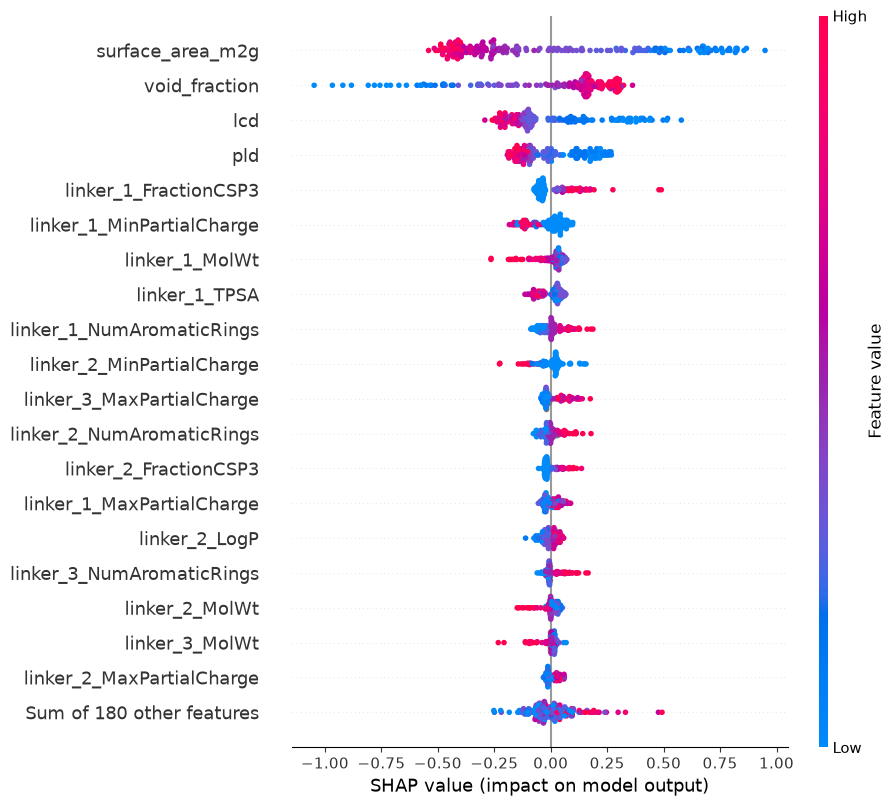


Structure + linker descriptors: CO2_uptake_0.5bar_molkg


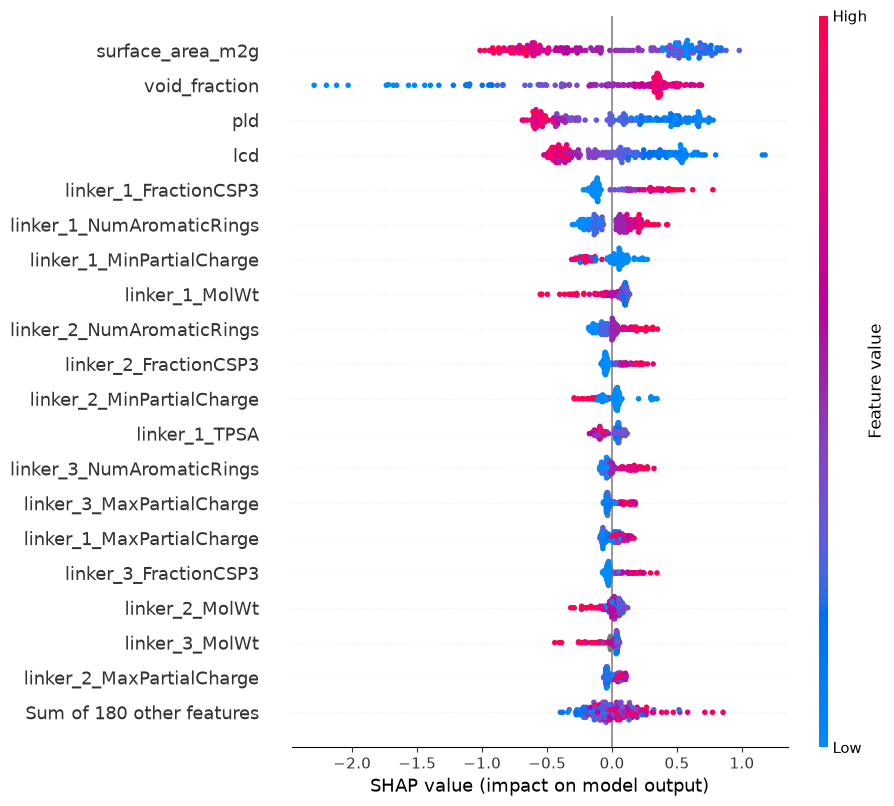


Structure + linker descriptors: CO2_uptake_2.5bar_molkg


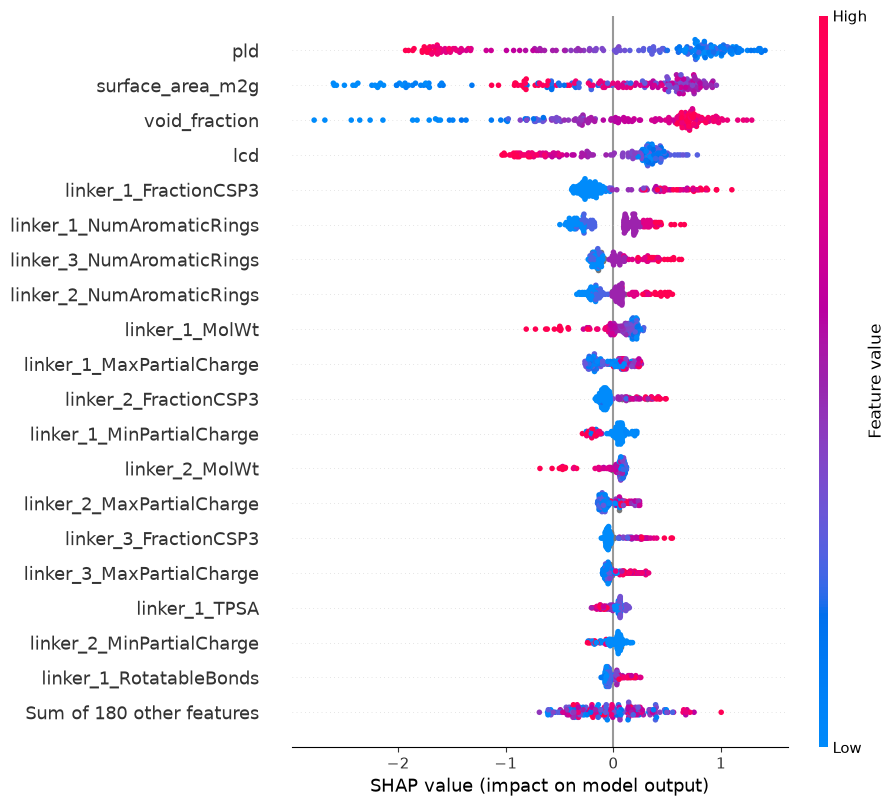

In [60]:
# Select the same validation rows used in the four-feature cell
X_shap_all = X_valid_all.loc[sample_index]

# Store the structure + linker SHAP results
shap_results_all = {}

# Fit and explain one structure + linker model per pressure
for target in target_cols:

    # Create the XGBoost model with the same settings
    model_all = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=1,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

    # Fit using structural features and numeric linker descriptors
    model_all.fit(X_train_all, df_train[target])

    # Calculate SHAP values for the selected validation rows
    shap_values_all = shap.TreeExplainer(model_all)(X_shap_all)

    # Save the explanation for this pressure
    shap_results_all[target] = shap_values_all

    # Display the top 20 individual feature columns
    print(f"\nStructure + linker descriptors: {target}")
    shap.plots.beeswarm(shap_values_all, max_display=20)

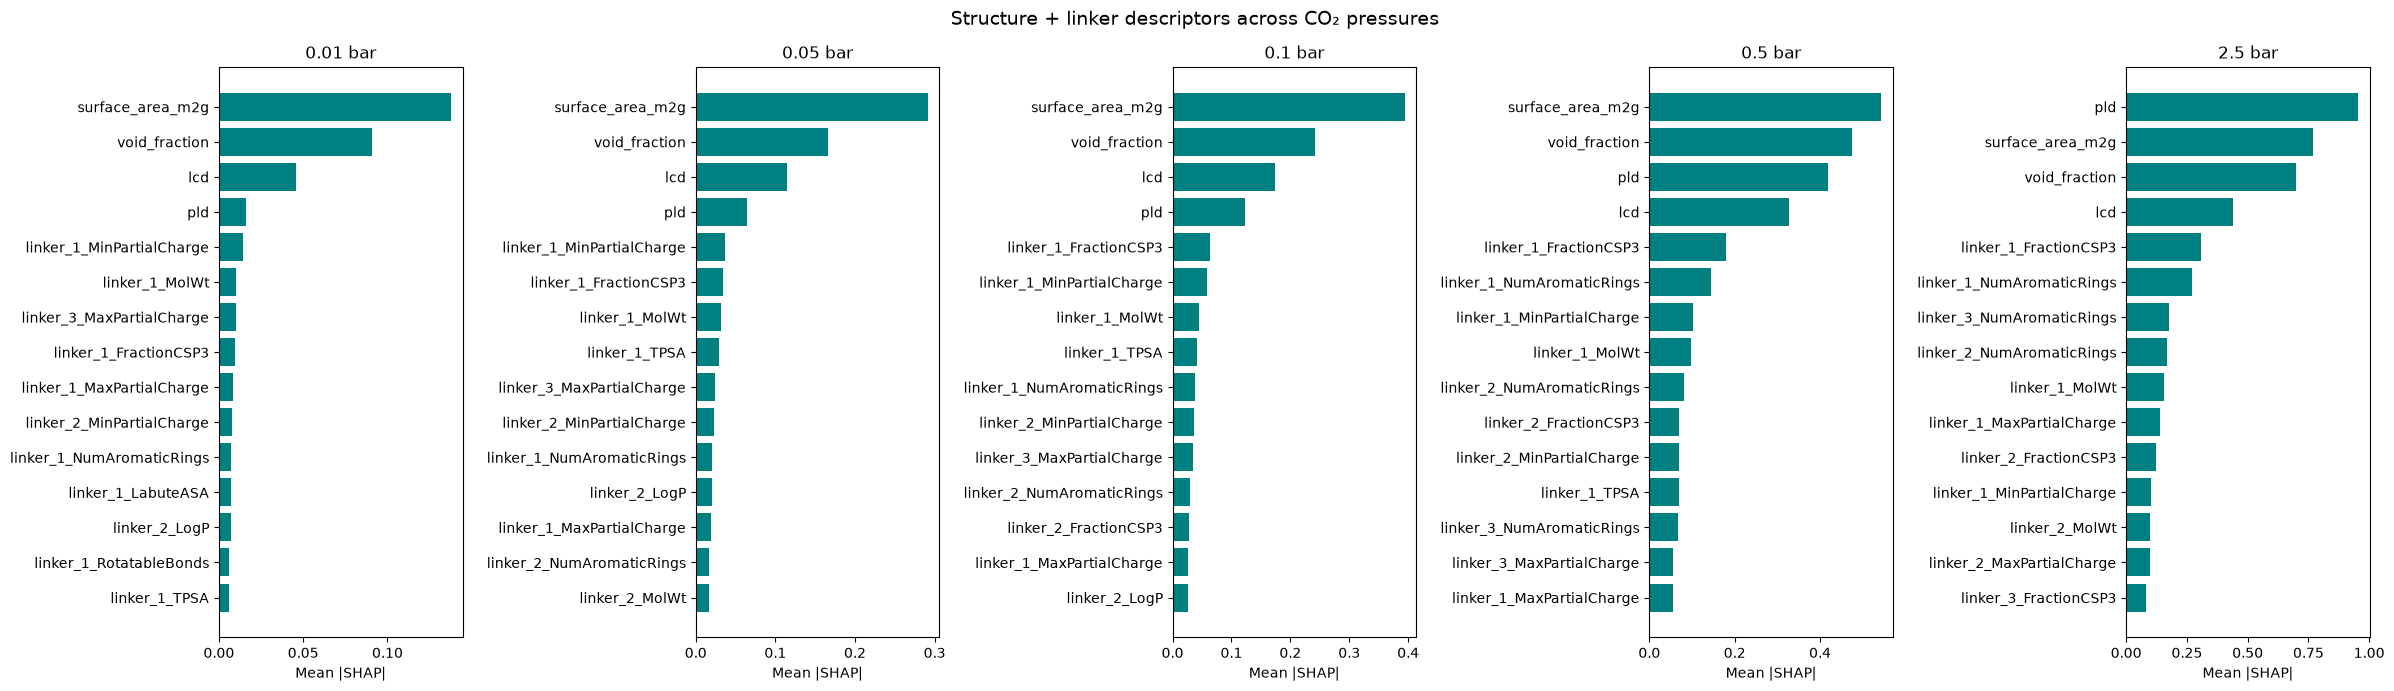

In [61]:
# Create a second figure showing the top 15 columns at each pressure
fig, axes = plt.subplots(1, 5, figsize=(24, 7))

for ax, target in zip(axes, target_cols):
    # Calculate mean absolute SHAP value for every structural and linker column
    values = shap_results[target]["with_linkers"]
    importance = np.abs(values.values).mean(axis=0)

    # Select the 15 most influential individual columns
    top_indices = np.argsort(importance)[-15:]

    # Plot their importance for this pressure
    ax.barh(
        np.array(values.feature_names)[top_indices],
        importance[top_indices],
        color="teal",
    )
    ax.set_title(target.split("_")[2].replace("bar", " bar"))
    ax.set_xlabel("Mean |SHAP|")

fig.suptitle("Structure + linker descriptors across CO₂ pressures", fontsize=14)
plt.tight_layout()
plt.show()

In [62]:


# Select the saved SHAP explanation for the full-feature model at 0.01 bar
target = "CO2_uptake_0.01bar_molkg"
values = shap_results_all[target]

# Calculate mean absolute SHAP importance for every feature
feature_importance = pd.DataFrame({
    "feature": values.feature_names,
    "mean_abs_SHAP": np.abs(values.values).mean(axis=0),
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    "mean_abs_SHAP",
    ascending=False,
)

# Display the top 20 individual features
display(feature_importance.head(20))

,feature,mean_abs_SHAP
3,surface_area_m2g,0.137624
2,void_fraction,0.090588
0,lcd,0.045451
1,pld,0.016270
10,linker_1_MinPartialCharge,0.014302
4,linker_1_MolWt,0.010345
39,linker_3_MaxPartialCharge,0.010247
16,linker_1_FractionCSP3,0.009320
9,linker_1_MaxPartialCharge,0.008512
25,linker_2_MinPartialCharge,0.007701
